In [1]:
import sys

In [2]:
sys.path.append("../src")
sys.path.append("..")

In [3]:
from gge import sensors

In [ ]:
nl= 31.42095
sl = 31.42085
wl = 34.3851
el = 34.3853



In [ ]:

area = (wl, sl, el, nl)  # Define the area

In [168]:
# Create a Landsat instance and use it
sentinel1 = sensors.Sentinel1()

sentinel1.area = area
sentinel1.time_range = ('2020-10-01', '2020-12-30') 
sentinel1.download_data()
data20 = sentinel1.images_data


2025-06-19 18:05:48,423 - root - INFO - download_data executed in 110.518 seconds. (exception_handler.py:10)


In [193]:
data20["vv_mean"]

array([ -6.75264133,  -5.82180497,  -7.36821914, -10.12094122,
        -5.79734038,  -5.7174315 , -11.35033936,  -4.97080821,
        -6.17484733, -10.11541818,  -5.01844418,  -0.33266246,
       -11.21112164,  -4.76325219,  -5.93360914,  -8.94296364,
        -5.62215559,  -7.18556477,  -8.23790354,  -6.16628297,
        -7.36939434,  -9.54564037,  -5.80397888,  -4.74697846,
        -8.68070848,  -6.83818548,  -5.86302413,  -8.8335739 ,
        -4.59715296,  -5.45481102,  -7.93233917,  -7.63411004,
        -5.9065386 ,  -7.75107478,  -4.97347664,  -5.60135133,
        -7.76849855,  -7.97753117,  -7.21206567,  -6.87163517,
        -5.01826168,  -5.08791362,  -7.21378251,  -6.24108502])

In [ ]:




sentinel1.time_range = ('2021-01-01', '2021-12-30') 
sentinel1.download_data()
data21 = sentinel1.images_data


sentinel1.time_range = ('2022-01-01', '2022-12-30') 
sentinel1.download_data()
data22 = sentinel1.images_data


sentinel1.time_range = ('2023-01-01', '2023-12-30') 
sentinel1.download_data()
data23 = sentinel1.images_data

2025-06-19 17:14:35,385 - root - INFO - download_data executed in 467.577 seconds. (exception_handler.py:10)
2025-06-19 17:21:46,555 - root - INFO - download_data executed in 431.168 seconds. (exception_handler.py:10)
2025-06-19 17:24:50,852 - root - INFO - download_data executed in 184.295 seconds. (exception_handler.py:10)
2025-06-19 17:27:52,212 - root - INFO - download_data executed in 181.356 seconds. (exception_handler.py:10)


In [72]:
len(sentinel1.images_data)

82

In [73]:
sentinel1.images_data[0]["image_bands"]["VV"].max()

np.float64(-3.049825167302463)

In [74]:
import numpy as np

In [92]:
data20 = dataforyear(data20)
data21 = dataforyear(data21)
data22 = dataforyear(data22)
data23 = dataforyear(data23)

In [184]:
data20 = dataforyear(data20)

In [185]:
data20

{'vv_mean': array([ -6.75264133,  -5.82180497,  -7.36821914, -10.12094122,
         -5.79734038,  -5.7174315 , -11.35033936,  -4.97080821,
         -6.17484733, -10.11541818,  -5.01844418,  -0.33266246,
        -11.21112164,  -4.76325219,  -5.93360914,  -8.94296364,
         -5.62215559,  -7.18556477,  -8.23790354,  -6.16628297,
         -7.36939434,  -9.54564037,  -5.80397888,  -4.74697846,
         -8.68070848,  -6.83818548,  -5.86302413,  -8.8335739 ,
         -4.59715296,  -5.45481102,  -7.93233917,  -7.63411004,
         -5.9065386 ,  -7.75107478,  -4.97347664,  -5.60135133,
         -7.76849855,  -7.97753117,  -7.21206567,  -6.87163517,
         -5.01826168,  -5.08791362,  -7.21378251,  -6.24108502]),
 'vh_mean': array([-12.021335  ,  -8.33360748, -14.15325633, -12.5602897 ,
        -10.99602016, -13.28653859, -12.36627756,  -8.99252173,
        -14.45034624, -14.64122057,  -8.77144433,  -9.9507094 ,
        -14.20002699, -10.259627  , -14.15933163, -12.01856324,
        -10.0946

In [188]:
import pandas as pd
import numpy as np
import math
from datetime import datetime, timedelta

def detect_changes_all(
    data_all: dict,
    window_days: int = 14,
    z_thresh: float = 2.0,
    smoothing_days: int = 10
) -> pd.DataFrame:
    """
    Input:
      data_all['times']    – list of ISO timestamps spanning 2020–2023
      data_all['vv_mean']  – list of corresponding SAR amplitudes

    Steps:
      1) build a single DataFrame, extract year & filter Oct 1+ in all years
      2) split into hist (2020–22) & df23
      3) smooth df23 over `smoothing_days`
      4) for each df23 row, compute z_hist vs. same‐DOY ±window_days in hist
         and z_local vs. preceding window_days in smoothed df23
    """
    # 1) build & filter
    df = pd.DataFrame({
        'dt': pd.to_datetime(data_all['times']),
        'val': data_all['vv_mean']
    })
    df['year'] = df['dt'].dt.year
    # Oct 1 onward across all years
    df = df[df['dt'].dt.month >= 10]

    # 2) split
    df_hist = df[df['year'].isin([2020, 2021, 2022])].copy()
    df23   = df[df['year']==2023].sort_values('dt').set_index('dt').copy()

    # 3) smoothing
    df23['val_smooth'] = (
        df23['val']
        .rolling(f'{smoothing_days}D', center=True, min_periods=1)
        .mean()
    )
    df23 = df23.reset_index()

    # helper for z & p
    def z_p(sample, obs):
        if len(sample) < 2 or np.std(sample, ddof=1)==0:
            return np.nan, np.nan
        μ, σ = sample.mean(), sample.std(ddof=1)
        z = (obs - μ)/σ
        φ = 0.5*(1 + math.erf(abs(z)/math.sqrt(2)))
        return z, 2*(1-φ)

    # 4) loop
    records = []
    for _, row in df23.iterrows():
        t = row['dt']
        x = row['val_smooth']
        doy = t.timetuple().tm_yday

        # hist window: same DOY ± window_days
        mask = df_hist['dt'].dt.dayofyear.sub(doy).abs() <= window_days
        hist_vals = df_hist.loc[mask, 'val'].values

        # local window: preceding window_days in smoothed df23
        start_local = t - timedelta(days=window_days)
        loc_vals = df23.loc[
            (df23['dt'] >= start_local) & (df23['dt'] < t),
            'val_smooth'
        ].values

        zh, ph = z_p(hist_vals, x)
        zl, pl = z_p(loc_vals,  x)
        flag = (abs(zh or 0)>z_thresh) or (abs(zl or 0)>z_thresh)

        records.append({
            'timestamp':    t,
            'value_raw':    row['val'],
            'value_smooth': x,
            'z_hist':       zh,  'p_hist': ph,
            'z_local':      zl,  'p_local': pl,
            'flag_change':  flag
        })

    return pd.DataFrame.from_records(records)

# — use it like this —
df_changes = detect_changes_all(data20)



In [190]:
df_changes

""


In [162]:
len(data21["vh_mean"])

614

In [183]:
def dataforyear(images_data):

    vv_mean = []
    vh_mean = []
    times = []

    for i in range(len(images_data)):
        vv_mean.append(images_data[i]["image_bands"]["VV"].mean())
        vh_mean.append(images_data[i]["image_bands"]["VH"].mean())
        times.append(images_data[i]["time"])
    vv_mean = np.array(vv_mean)
    vh_mean = np.array(vh_mean)

    data = {
        "vv_mean": vv_mean,
        "vh_mean": vh_mean,
        "times": times}
    return data

In [76]:
import matplotlib.pyplot as plt 

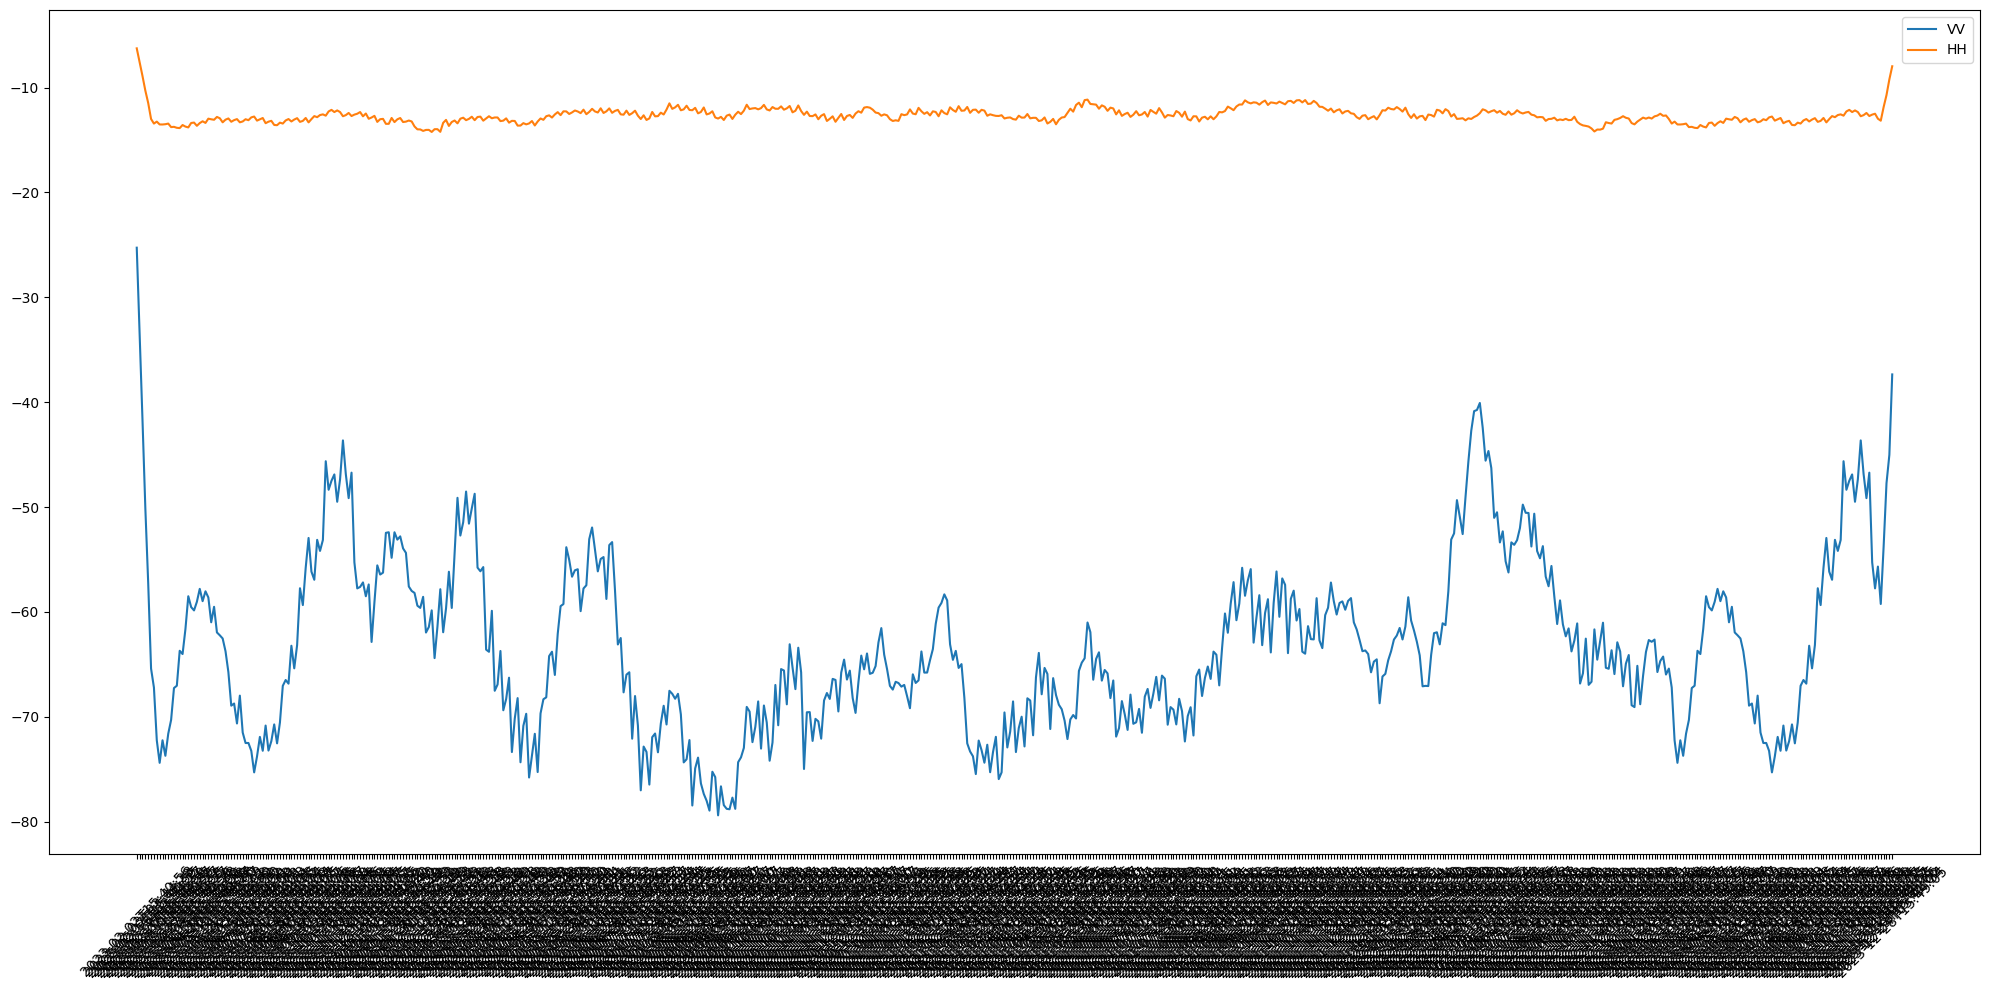

In [95]:
plot_year(data20)

In [93]:
import matplotlib.pyplot as plt


def plot_year(data20):
    vv_mean_smooth = np.convolve(data20["vv_mean"], np.ones(10)/1, mode='same')
    vh_mean_smooth = np.convolve(data20["vh_mean"], np.ones(10)/10, mode='same')


    # Example: timestamps must match length of vv_mean and hh_mean
    # timestamps = ['2023-01-01', '2023-01-02', ..., '2023-01-10']
    plt.figure(figsize=(20, 10))
    plt.plot(vv_mean_smooth, label='VV')
    plt.plot(vh_mean_smooth, label='HH')

    plt.xticks(ticks=range(len(data20["times"])), labels=data20["times"], rotation=45)
    plt.legend()
    plt.tight_layout()  # Avoid clipping of rotated labels
    plt.show()

    

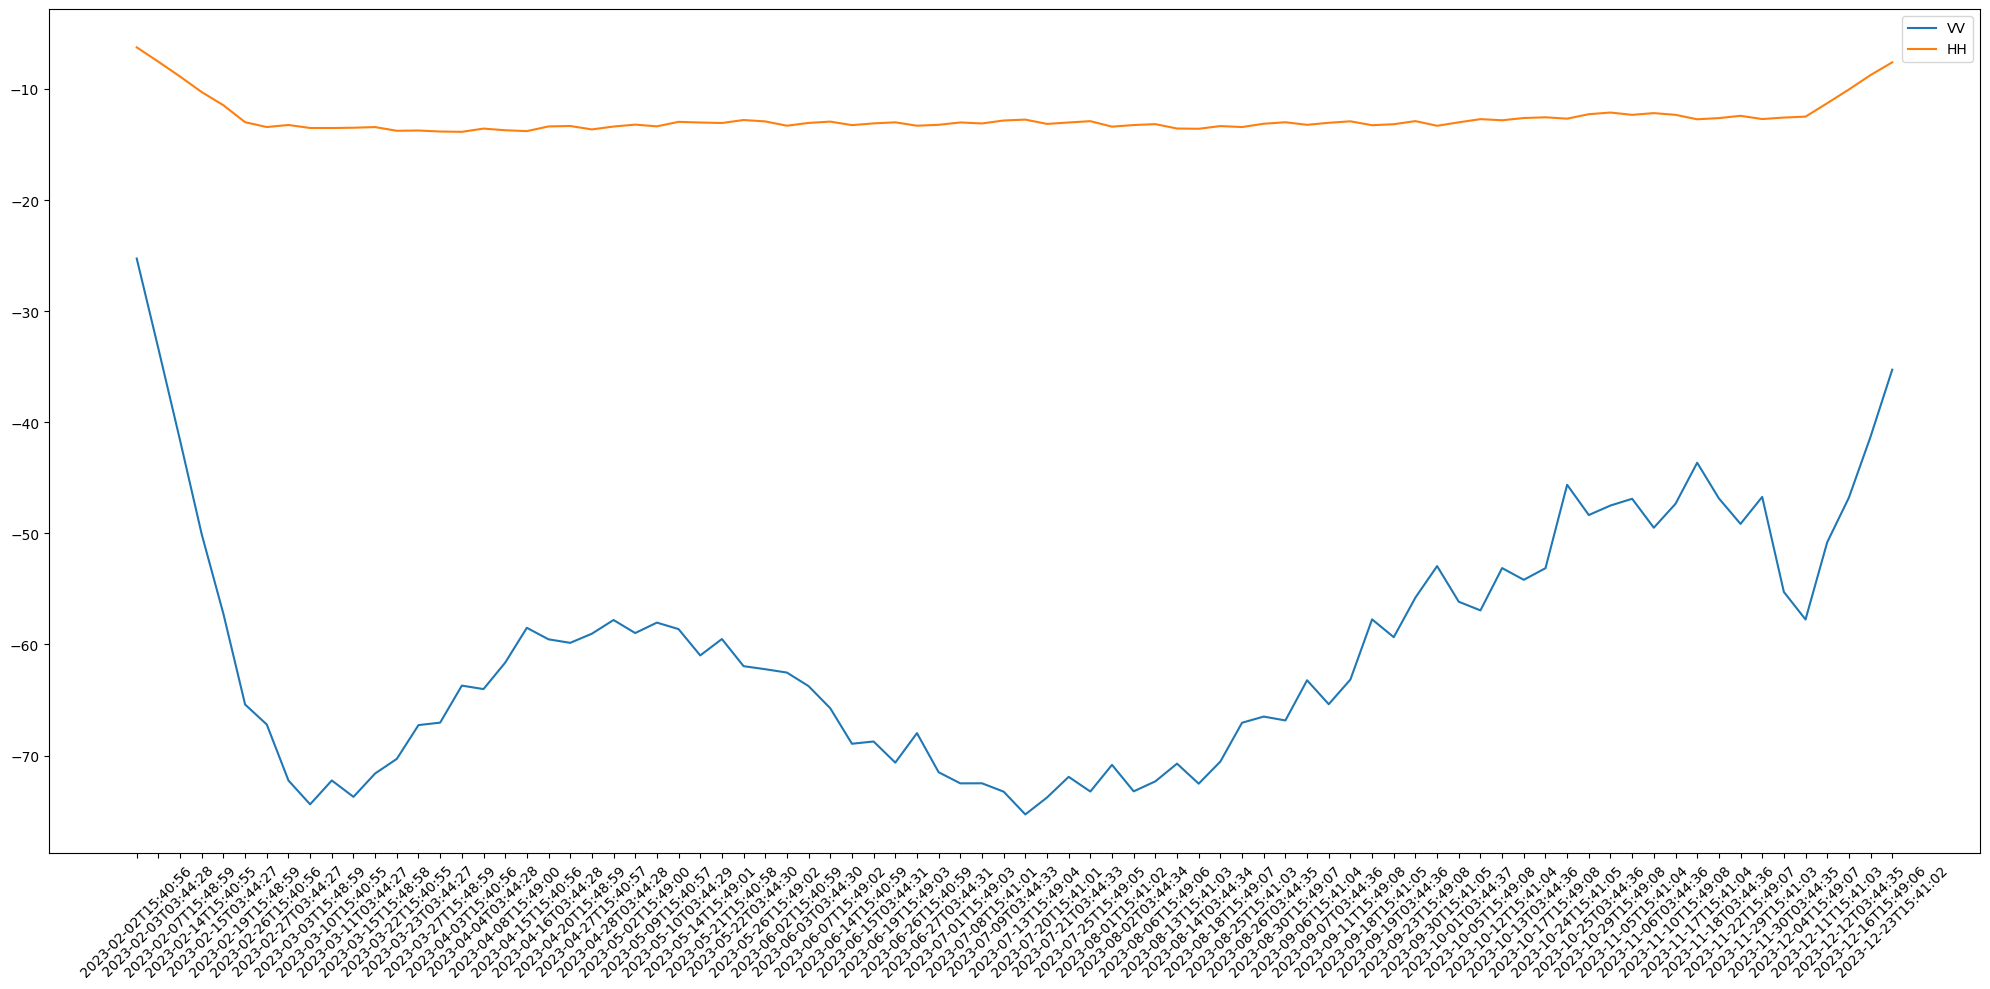

In [54]:
sentinel1.images_data[4]["time"]

'2023-10-17T15:49:08'

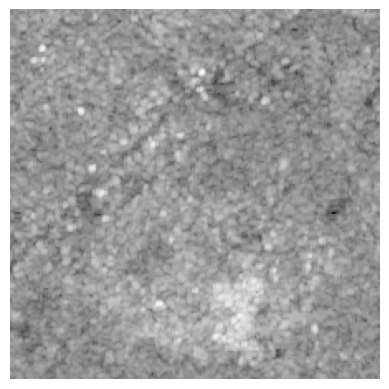

In [55]:
sentinel1.display_rgb(3,bands = ["VV"], gain = 1, gamma = 0.7)

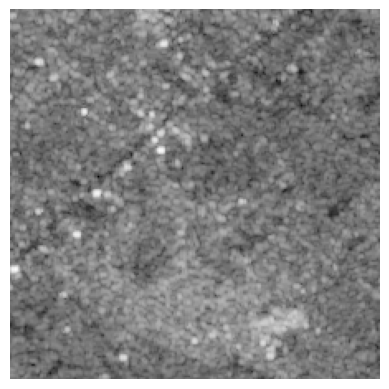

In [56]:
sentinel1.display_rgb(4,bands = ["VV"], gain = 1, gamma = 0.7)

In [164]:
import pandas as pd
import numpy as np
import math
from datetime import datetime, timedelta

def detect_changes_all(
    data_all: dict,
    window_days: int = 14,
    z_thresh: float = 2.0,
    smoothing_days: int = 10
) -> pd.DataFrame:
    """
    Input:
      data_all['times']    – list of ISO timestamps spanning 2020–2023
      data_all['vv_mean']  – list of corresponding SAR amplitudes

    Steps:
      1) build a single DataFrame, extract year & filter Oct 1+ in all years
      2) split into hist (2020–22) & df23
      3) smooth df23 over `smoothing_days`
      4) for each df23 row, compute z_hist vs. same‐DOY ±window_days in hist
         and z_local vs. preceding window_days in smoothed df23
    """
    # 1) build & filter
    df = pd.DataFrame({
        'dt': pd.to_datetime(data_all['times']),
        'val': data_all['vv_mean']
    })
    df['year'] = df['dt'].dt.year
    # Oct 1 onward across all years
    df = df[df['dt'].dt.month >= 10]

    # 2) split
    df_hist = df[df['year'].isin([2020, 2021, 2022])].copy()
    df23   = df[df['year']==2023].sort_values('dt').set_index('dt').copy()

    # 3) smoothing
    df23['val_smooth'] = (
        df23['val']
        .rolling(f'{smoothing_days}D', center=True, min_periods=1)
        .mean()
    )
    df23 = df23.reset_index()

    # helper for z & p
    def z_p(sample, obs):
        if len(sample) < 2 or np.std(sample, ddof=1)==0:
            return np.nan, np.nan
        μ, σ = sample.mean(), sample.std(ddof=1)
        z = (obs - μ)/σ
        φ = 0.5*(1 + math.erf(abs(z)/math.sqrt(2)))
        return z, 2*(1-φ)

    # 4) loop
    records = []
    for _, row in df23.iterrows():
        t = row['dt']
        x = row['val_smooth']
        doy = t.timetuple().tm_yday

        # hist window: same DOY ± window_days
        mask = df_hist['dt'].dt.dayofyear.sub(doy).abs() <= window_days
        hist_vals = df_hist.loc[mask, 'val'].values

        # local window: preceding window_days in smoothed df23
        start_local = t - timedelta(days=window_days)
        loc_vals = df23.loc[
            (df23['dt'] >= start_local) & (df23['dt'] < t),
            'val_smooth'
        ].values

        zh, ph = z_p(hist_vals, x)
        zl, pl = z_p(loc_vals,  x)
        flag = (abs(zh or 0)>z_thresh) or (abs(zl or 0)>z_thresh)

        records.append({
            'timestamp':    t,
            'value_raw':    row['val'],
            'value_smooth': x,
            'z_hist':       zh,  'p_hist': ph,
            'z_local':      zl,  'p_local': pl,
            'flag_change':  flag
        })

    return pd.DataFrame.from_records(records)




In [165]:
# — use it like this —
df_changes = detect_changes_all(data23)


In [167]:
df_changes

,timestamp,value_raw,value_smooth,z_hist,p_hist,z_local,p_local,flag_change
0,2023-10-01 03:44:37,-2.033121,-4.921916,0.913016,0.361234,NaN,NaN,False
1,2023-10-01 03:44:37,-2.033121,-4.921916,0.913016,0.361234,NaN,NaN,False
2,2023-10-05 15:49:08,-7.810712,-4.921916,0.715967,0.474011,NaN,NaN,False
3,2023-10-05 15:49:08,-7.810712,-4.921916,0.715967,0.474011,NaN,NaN,False
4,2023-10-12 15:41:04,-4.618490,-3.750679,1.112934,0.265737,NaN,NaN,False
5,2023-10-12 15:41:04,-4.618490,-3.750679,1.112934,0.265737,NaN,NaN,False
6,2023-10-13 03:44:36,-2.882867,-5.227720,0.553267,0.580081,-1.151105,2.496890e-01,False
7,2023-10-13 03:44:36,-2.882867,-5.227720,0.553267,0.580081,-1.151105,2.496890e-01,False
8,2023-10-17 15:49:08,-8.181804,-5.532336,0.336241,0.736689,-1.289065,1.973756e-01,False
9,2023-10-17 15:49:08,-8.181804,-5.532336,0.336241,0.736689,-1.289065,1.973756e-01,False


In [104]:
df = detect_changes(data20, data21, data22, data23, window_days= 15, z_thresh=2.0)

In [115]:
df2 = detect_changes2(data20, data21, data22, data23, window_days= 15, z_thresh=2.0)

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ——————————————————————————————
# PREP
# ——————————————————————————————
# assume you already have:
#   df: DataFrame with cols ['timestamp','value','z_hist','z_local','flag_change',…]
# convert & extract
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year']      = df['timestamp'].dt.year
df['doy']       = df['timestamp'].dt.dayofyear


In [116]:
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2['year']      = df2['timestamp'].dt.year
df2['doy']       = df2['timestamp'].dt.dayofyear

In [120]:
df_this = df2.copy()
df_this.dropna(how='any') 

,timestamp,value_raw,value_smooth,z_hist,p_hist,z_local,p_local,flag_change,year,doy
3,2020-01-08 03:43:40,-4.904579,-6.633290,-0.267905,0.788773,-3.202049,0.001365,True,2020,8
4,2020-01-12 15:47:52,-8.187079,-5.076294,0.734713,0.462514,0.946810,0.343736,False,2020,12
5,2020-01-13 15:40:39,-3.872905,-5.133532,0.698125,0.485099,0.698672,0.484757,False,2020,13
6,2020-01-14 03:44:19,-3.340612,-4.965467,0.805556,0.420499,0.892485,0.372133,False,2020,14
7,2020-01-18 15:48:42,-4.461271,-4.571771,1.035347,0.300507,1.357521,0.174616,False,2020,18
...,...,...,...,...,...,...,...,...,...,...
609,2023-12-16 15:49:06,-7.227128,-5.405800,0.925643,0.354632,0.068721,0.945212,False,2023,350
610,2023-12-23 15:41:02,-7.237039,-6.449532,0.077102,0.938542,-3.062362,0.002196,True,2023,357
611,2023-12-23 15:41:02,-7.237039,-6.449532,0.077102,0.938542,-3.062362,0.002196,True,2023,357
612,2023-12-24 03:44:34,-4.874519,-6.731985,-0.189719,0.849529,-1.945437,0.051722,False,2023,358


In [132]:
# keep only Oct. 1 onward across all years
df_this = df_this[df_this['timestamp'].dt.month >= 9]

# and if you want to work inside detect_changes(), right after you build each DF:
#df_hist = df_hist[df_hist['dt'].dt.month >= 10]
#df23   = df23[df23['dt'].dt.month >= 10]


In [129]:
df_this

,timestamp,value_raw,value_smooth,z_hist,p_hist,z_local,p_local,flag_change,year,doy
134,2020-10-02 15:48:01,-6.752641,-6.606918,-0.203669,0.838612,1.092363,0.274673,False,2020,276
135,2020-10-03 15:40:48,-5.821805,-6.647555,-0.259168,0.795506,0.849518,0.395593,False,2020,277
136,2020-10-04 03:44:28,-7.368219,-7.515902,-0.625636,0.531554,-1.102838,0.270097,False,2020,278
137,2020-10-08 15:48:51,-10.120941,-7.250983,-0.512849,0.608057,-1.250543,0.211101,False,2020,282
138,2020-10-09 15:39:57,-5.797340,-7.211904,-0.507457,0.611834,-0.932142,0.351263,False,2020,283
...,...,...,...,...,...,...,...,...,...,...
609,2023-12-16 15:49:06,-7.227128,-5.405800,0.925643,0.354632,0.068721,0.945212,False,2023,350
610,2023-12-23 15:41:02,-7.237039,-6.449532,0.077102,0.938542,-3.062362,0.002196,True,2023,357
611,2023-12-23 15:41:02,-7.237039,-6.449532,0.077102,0.938542,-3.062362,0.002196,True,2023,357
612,2023-12-24 03:44:34,-4.874519,-6.731985,-0.189719,0.849529,-1.945437,0.051722,False,2023,358


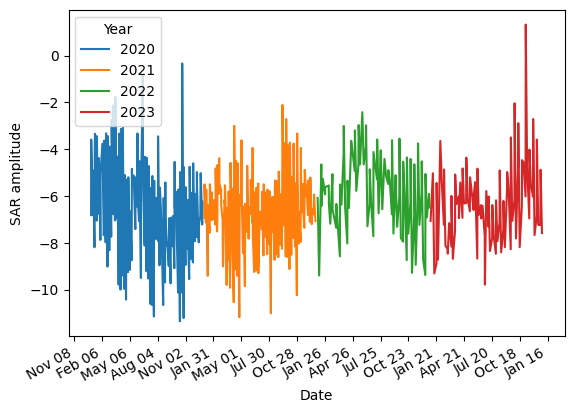

In [130]:
# 1) LINE PLOT FOR EACH YEAR
fig, ax = plt.subplots()
for year, group in df.groupby('year'):
    ax.plot(group['timestamp'], group['value'], label=str(year))
ax.set_xlabel('Date')
ax.set_ylabel('SAR amplitude')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=90))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(title='Year')
fig.autofmt_xdate()
plt.show()

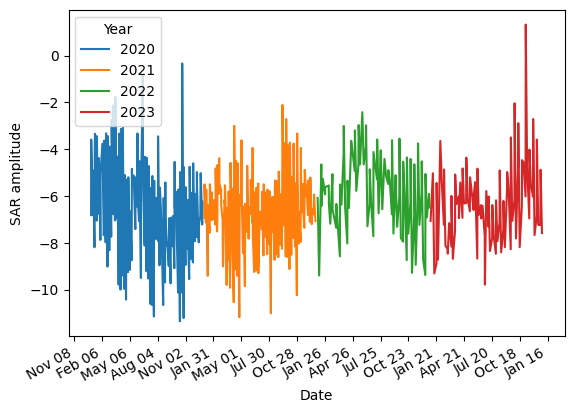

In [113]:
# 1) LINE PLOT FOR EACH YEAR
fig, ax = plt.subplots()
for year, group in df.groupby('year'):
    ax.plot(group['timestamp'], group['value'], label=str(year))
ax.set_xlabel('Date')
ax.set_ylabel('SAR amplitude')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=90))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(title='Year')
fig.autofmt_xdate()
plt.show()

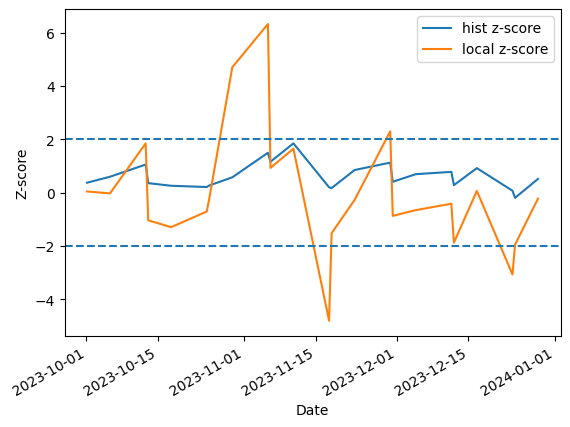

In [133]:

# 2) ANOMALIES IN 2023 (z-scores)
df23 = df_this[df_this['year']==2023]
fig, ax = plt.subplots()
ax.plot(df23['timestamp'], df23['z_hist'], label='hist z-score')
ax.plot(df23['timestamp'], df23['z_local'], label='local z-score')
ax.axhline( 2, linestyle='--'); ax.axhline(-2, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.legend()
fig.autofmt_xdate()
plt.show()


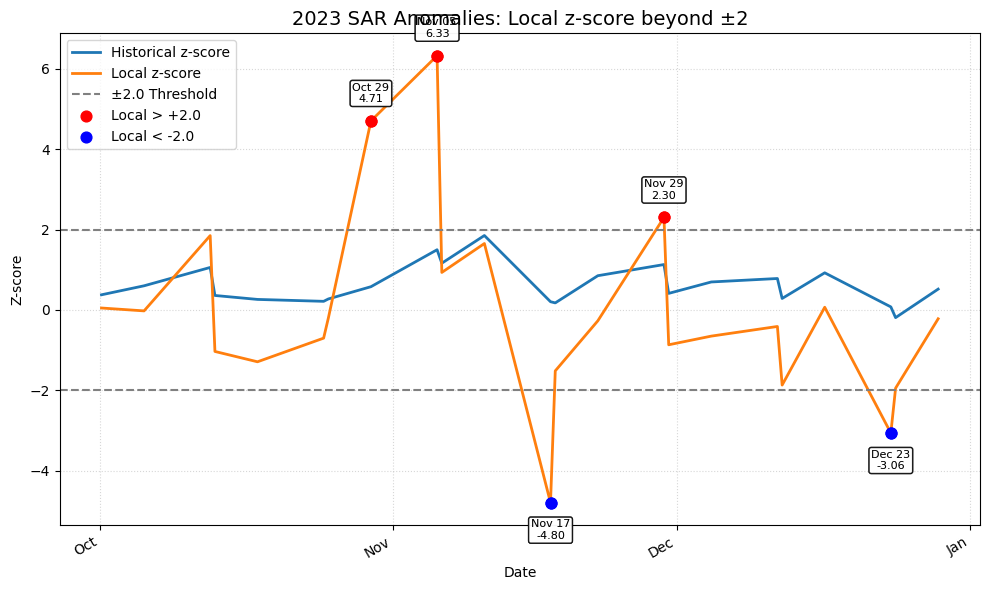

In [141]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# —————————————————————————————————————
# 2) ANOMALIES IN 2023 (z-scores) — threshold highlights
# —————————————————————————————————————
z_thresh = 2.0


# filter 2023
df23 = df_this[df_this['year'] == 2023]



# masks: local z-score beyond ±z_thresh
mask_pos = df23['z_local'] > z_thresh
mask_neg = df23['z_local'] < -z_thresh

# create figure
fig, ax = plt.subplots(figsize=(10, 6))

# plot the two z-score series
ax.plot(df23['timestamp'], df23['z_hist'],
        label='Historical z-score', linewidth=2)
ax.plot(df23['timestamp'], df23['z_local'],
        label='Local z-score',      linewidth=2)

# add threshold lines at ±z_thresh
ax.axhline( z_thresh, color='gray', linestyle='--', label=f'±{z_thresh} Threshold')
ax.axhline(-z_thresh, color='gray', linestyle='--')

# highlight where local z-score exceeds threshold
ax.scatter(df23.loc[mask_pos, 'timestamp'],
           df23.loc[mask_pos, 'z_local'],
           color='red',   s=60, zorder=5,
           label=f'Local > +{z_thresh}')
ax.scatter(df23.loc[mask_neg, 'timestamp'],
           df23.loc[mask_neg, 'z_local'],
           color='blue',  s=60, zorder=5,
           label=f'Local < -{z_thresh}')

# annotate each highlighted point with date and z-value
for mask, va in [(mask_pos, 'bottom'), (mask_neg, 'top')]:
    for t, z in zip(df23.loc[mask, 'timestamp'], df23.loc[mask, 'z_local']):
        ax.annotate(
            f"{t.strftime('%b %d')}\n{z:.2f}",
            xy=(t, z),
            xytext=(0, 12 if va=='bottom' else -12),
            textcoords='offset points',
            ha='center',
            va=va,
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8)
        )

# styling
ax.set_title('2023 SAR Anomalies: Local z-score beyond ±2', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(frameon=True, loc='upper left')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [151]:
data21["times"][239]

'2020-11-15T03:43:48'

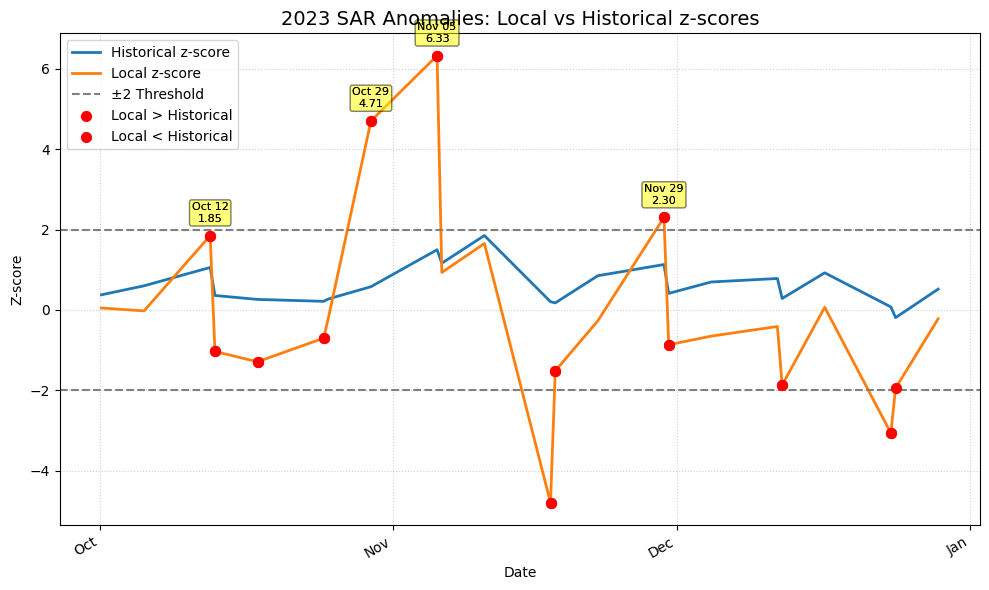

In [137]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# —————————————————————————————————————
# 2) ANOMALIES IN 2023 (z-scores) — improved
# —————————————————————————————————————

# filter 2023
df23 = df_this[df_this['year'] == 2023]

# mask where local z-score exceeds historical z-score
mask = df23['z_local'] > df23['z_hist']
mask2 = df23['z_local'] < -df23['z_hist']

# create figure
fig, ax = plt.subplots(figsize=(10, 6))

# plot the two z-score series
ax.plot(df23['timestamp'], df23['z_hist'],
        label='Historical z-score', linewidth=2)
ax.plot(df23['timestamp'], df23['z_local'],
        label='Local z-score',      linewidth=2)

# add threshold lines at ±2
ax.axhline( 2, color='gray', linestyle='--', label='±2 Threshold')
ax.axhline(-2, color='gray', linestyle='--')

# highlight points where local > historical
ax.scatter(df23.loc[mask, 'timestamp'],
           df23.loc[mask, 'z_local'],
           color='red',
           s=50,
           zorder=5,
           label='Local > Historical')


ax.scatter(df23.loc[mask2, 'timestamp'],
           df23.loc[mask2, 'z_local'],
           color='red',
           s=50,
           zorder=5,
           label='Local < Historical')




# annotate each highlighted point with date and z-value
for t, z in zip(df23.loc[mask, 'timestamp'], df23.loc[mask, 'z_local']):
    label = f"{t.strftime('%b %d')}\n{z:.2f}"
    ax.annotate(label,
                xy=(t, z),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3))

# styling
ax.set_title('2023 SAR Anomalies: Local vs Historical z-scores', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(frameon=True, loc='upper left')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


KeyError: 'value'

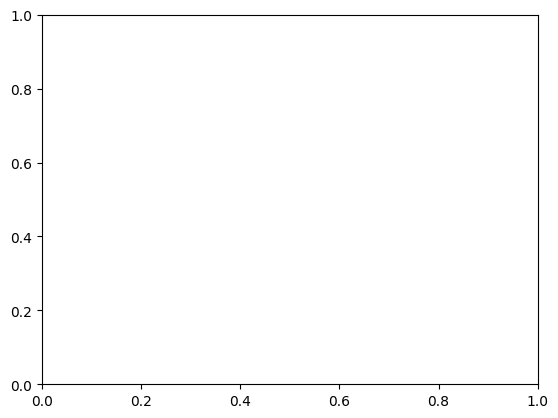

In [125]:
oct_df = df_this[(df_this['doy'] >= 274) & (df_this['doy'] <= 304)]
fig, ax = plt.subplots()
for year, grp in oct_df.groupby('year'):
    ax.plot(grp['doy'], grp['value'], label=str(year))
ax.set_xlabel('Day of Year (Oct)')
ax.set_ylabel('SAR Amplitude')
ax.legend(title='Year')
plt.show()


In [127]:
df_this

,timestamp,value_raw,value_smooth,z_hist,p_hist,z_local,p_local,flag_change,year,doy
0,2020-01-01 15:40:40,-6.813985,-5.199145,0.643070,0.520178,NaN,NaN,False,2020,1
1,2020-01-02 03:44:20,-3.584304,-5.199145,0.643070,0.520178,NaN,NaN,False,2020,2
2,2020-01-07 15:39:49,-6.808211,-5.856395,0.198908,0.842335,NaN,NaN,False,2020,7
3,2020-01-08 03:43:40,-4.904579,-6.633290,-0.267905,0.788773,-3.202049,0.001365,True,2020,8
4,2020-01-12 15:47:52,-8.187079,-5.076294,0.734713,0.462514,0.946810,0.343736,False,2020,12
...,...,...,...,...,...,...,...,...,...,...
609,2023-12-16 15:49:06,-7.227128,-5.405800,0.925643,0.354632,0.068721,0.945212,False,2023,350
610,2023-12-23 15:41:02,-7.237039,-6.449532,0.077102,0.938542,-3.062362,0.002196,True,2023,357
611,2023-12-23 15:41:02,-7.237039,-6.449532,0.077102,0.938542,-3.062362,0.002196,True,2023,357
612,2023-12-24 03:44:34,-4.874519,-6.731985,-0.189719,0.849529,-1.945437,0.051722,False,2023,358


KeyError: 'value'

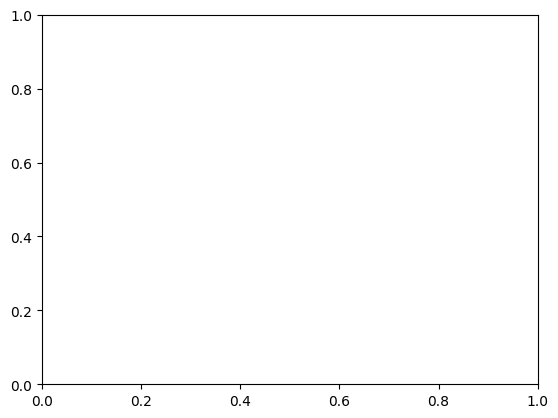

In [126]:
import matplotlib.pyplot as plt

# assume df has cols ['doy','year','value']
fig, ax = plt.subplots()
for year, grp in df_this.groupby('year'):
    ax.plot(grp['doy'], grp['value'], label=str(year))
ax.set_xlabel('Day of Year')
ax.set_ylabel('SAR Amplitude')
ax.set_xlim(274, 304)        # roughly Oct 1–31
ax.legend(title='Year')
plt.show()


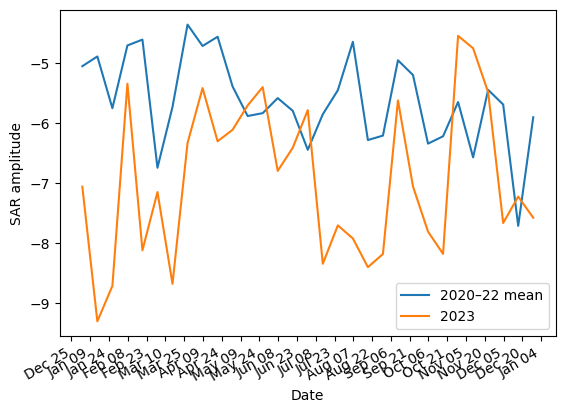

In [108]:


# 3) MEAN OF 2020–2022 VS 2023
hist = df[df['year'].isin([2020,2021,2022])]
baseline = (
    hist
    .groupby('doy')['value']
    .mean()
    .rename('mean_val')
    .reset_index()
)
merged = df23.merge(baseline, on='doy')
fig, ax = plt.subplots()
ax.plot(merged['timestamp'], merged['mean_val'], label='2020–22 mean')
ax.plot(merged['timestamp'], merged['value'],    label='2023')
ax.set_xlabel('Date')
ax.set_ylabel('SAR amplitude')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend()
fig.autofmt_xdate()
plt.show()

In [114]:



import numpy as np
import math
import pandas as pd
from datetime import datetime, timedelta

def detect_changes2(
    data20, data21, data22, data23,
    window_days: int = 14,
    z_thresh: float = 2.0,
    smoothing_days: int = 10
) -> pd.DataFrame:
    """
    As before, but first smooth the 2023 values with a centered rolling mean
    over `smoothing_days` days, then compute all z-scores on that smoothed series.
    """
    def to_dt(x):
        return x if isinstance(x, datetime) else datetime.fromisoformat(x)

    # unpack
    ts20, v20 = data20["times"], data20["vv_mean"]
    ts21, v21 = data21["times"], data21["vv_mean"]
    ts22, v22 = data22["times"], data22["vv_mean"]
    ts23, v23 = data23["times"], data23["vv_mean"]

    # historical DataFrame (2020–22)
    df_hist = pd.concat([
        pd.DataFrame({'dt': list(map(to_dt, ts)), 'val': vals})
        for ts, vals in [(ts20, v20), (ts21, v21), (ts22, v22)]
    ], ignore_index=True)

    # 2023 DataFrame + smoothing
    df23 = pd.DataFrame({
        'dt': list(map(to_dt, ts23)),
        'val': v23
    }).set_index('dt').sort_index()
    df23['val_smooth'] = (
        df23['val']
        .rolling(f'{smoothing_days}D', center=True, min_periods=1)
        .mean()
    )
    df23 = df23.reset_index()

    out = []
    for _, row in df23.iterrows():
        t = row['dt']
        x = row['val_smooth']    # use smoothed value
        doy = t.timetuple().tm_yday

        # hist window
        mask = df_hist['dt'].apply(
            lambda d: abs(d.timetuple().tm_yday - doy) <= window_days
        )
        hist_vals = df_hist.loc[mask, 'val'].values

        # local window on smoothed 2023
        start_local = t - timedelta(days=window_days)
        loc_vals = df23.loc[
            (df23['dt'] >= start_local) & (df23['dt'] < t),
            'val_smooth'
        ].values

        def z_p(sample, obs):
            if len(sample) < 2 or np.std(sample, ddof=1)==0:
                return np.nan, np.nan
            μ, σ = sample.mean(), sample.std(ddof=1)
            z = (obs - μ)/σ
            φ = 0.5*(1 + math.erf(abs(z)/math.sqrt(2)))
            return z, 2*(1-φ)

        zh, ph = z_p(hist_vals, x)
        zl, pl = z_p(loc_vals,  x)
        flag = (abs(zh or 0)>z_thresh) or (abs(zl or 0)>z_thresh)

        out.append({
            'timestamp':   t,
            'value_raw':   row['val'],
            'value_smooth':x,
            'z_hist':      zh, 'p_hist': ph,
            'z_local':     zl, 'p_local':pl,
            'flag_change': flag
        })

    return pd.DataFrame(out)



In [101]:
import numpy as np
import math
import pandas as pd
from datetime import datetime, timedelta

def detect_changes(
    data20, data21, data22, data23,
    window_days: int = 14,
    z_thresh: float = 2.0
) -> pd.DataFrame:
    """
    For each SAR amplitude in 2023, compute:
      - historical z-score vs. 2020–2022 values within ±window_days of the same day‐of‐year
      - local z-score vs. the preceding window_days in 2023

    Parameters
    ----------
    dataXX : tuple of (list of timestamps, list of floats)
        SAR data for year XX.
    window_days : int
        size of the day window for baselines (default=14)
    z_thresh : float
        threshold on |z| to flag a change (default=2.0)

    Returns
    -------
    pd.DataFrame with columns:
      timestamp, value,
      z_hist, p_hist,
      z_local, p_local,
      flag_change
    """
    # helper: parse to datetime
    def to_dt(x):
        return x if isinstance(x, datetime) else datetime.fromisoformat(x)

    # unpack
    ts20, vals20 = data20["times"], data20["vv_mean"]
    ts21, vals21 = data21["times"], data21["vv_mean"]
    ts22, vals22 = data22["times"], data22["vv_mean"]
    ts23, vals23 = data23["times"], data23["vv_mean"]

    # build historical DataFrame (2020–2022)
    df_hist = pd.concat([
        pd.DataFrame({
            'dt': list(map(to_dt, ts)),
            'val': vals
        })
        for ts, vals in [(ts20, vals20), (ts21, vals21), (ts22, vals22)]
    ], ignore_index=True)

    # 2023 DataFrame
    df23 = pd.DataFrame({
        'dt': list(map(to_dt, ts23)),
        'val': vals23
    }).sort_values('dt').reset_index(drop=True)

    records = []
    for _, row in df23.iterrows():
        t, x = row['dt'], row['val']
        doy = t.timetuple().tm_yday

        # 1) historical window: same DOY ± window_days in 2020–2022
        mask = df_hist['dt'].apply(
            lambda d: abs(d.timetuple().tm_yday - doy) <= window_days
        )
        hist_vals = df_hist.loc[mask, 'val'].values

        # 2) local window: preceding window_days in 2023
        start_local = t - timedelta(days=window_days)
        loc_vals = df23.loc[
            (df23['dt'] >= start_local) & (df23['dt'] < t),
            'val'
        ].values

        # compute z & two‐tailed p
        def z_p(sample, obs):
            if len(sample) < 2 or np.std(sample, ddof=1) == 0:
                return np.nan, np.nan
            mu, sigma = sample.mean(), sample.std(ddof=1)
            z = (obs - mu) / sigma
            # normal cdf via erf
            phi = 0.5 * (1 + math.erf(abs(z) / math.sqrt(2)))
            p = 2 * (1 - phi)
            return z, p

        zh, ph = z_p(hist_vals, x)
        zl, pl = z_p(loc_vals, x)
        flag = ((abs(zh or 0) > z_thresh) or (abs(zl or 0) > z_thresh))

        records.append({
            'timestamp': t,
            'value': x,
            'z_hist': zh, 'p_hist': ph,
            'z_local': zl, 'p_local': pl,
            'flag_change': flag
        })

    return pd.DataFrame.from_records(records)
